# Customer Churn Prediction
## Notebook 3 of 8 — Exploratory Data Analysis (EDA)

This project predicts which telecom customers are likely to **churn** (cancel their service) so the business can reach them with retention offers *before* they leave. It walks through the full data-science lifecycle — exploration, cleaning, EDA, feature engineering, modelling, evaluation, and a tuned final model.

**Business problem:** Winning a new customer costs far more than keeping an existing one. This telecom loses roughly **27% of its customers**, and the leadership team wants a reliable, data-driven way to flag at-risk customers early enough to act.

**Tools & techniques:** Python · pandas · NumPy · Matplotlib · Seaborn · scikit-learn · XGBoost · SMOTE (imbalanced-learn) · joblib

> **This notebook:** we visualise churn patterns across contract type, charges, payment method, and tenure to build intuition before modelling. Every chart is saved to outputs/figures/.

**Author:** La Yaung Linn Lett  &nbsp;·&nbsp;  **Last updated:** June 2026

---

## 1. Setup

**What:** Import the plotting libraries and load the cleaned dataset from Notebook 02.

**Why:** Loading the already-cleaned file (rather than re-cleaning) keeps this notebook focused purely on analysis.

In [1]:
# Standard library
import warnings

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("whitegrid")

# Load the cleaned data produced by notebook 02
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

# Folder where every figure is saved for the README / portfolio
FIG_DIR = "../outputs/figures"
df.head()

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Churn by contract type

**What:** Compare churn counts across month-to-month, one-year, and two-year contracts.

**Why:** Contract length is one of the strongest, most actionable churn drivers in subscription businesses — locked-in customers are harder to lose.

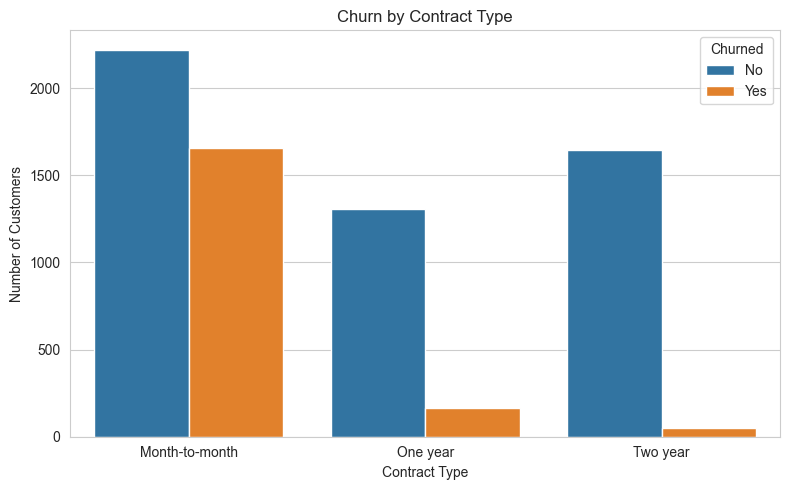

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churned")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Month-to-month customers churn dramatically more than those on one- or two-year contracts. Customers with no contractual lock-in are the highest-risk group — and the most obvious target for retention incentives (e.g. discounts to upgrade to an annual plan).

## 3. Churn by monthly charges

**What:** Compare the distribution of monthly charges for churned vs. retained customers.

**Why:** Price is a classic churn lever — we want to see whether higher bills push customers out the door.

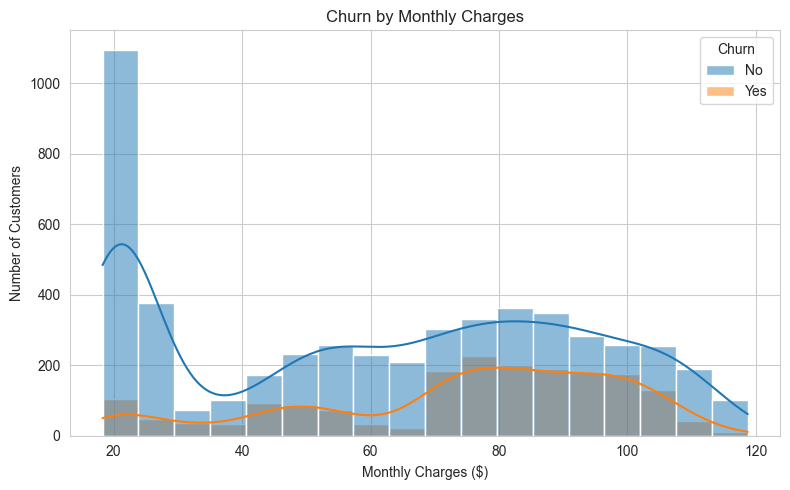

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)
plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/churn_by_monthly_charges.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Churn is concentrated among customers with **high monthly charges (~$70-$110)**, while low-bill customers rarely leave. High-paying customers are both the most valuable *and* the most flight-risky — a key segment to protect.

## 4. Churn by payment method

**What:** Compare churn across the four payment methods.

**Why:** Payment friction often correlates with churn, and payment method is an easy attribute to act on operationally.

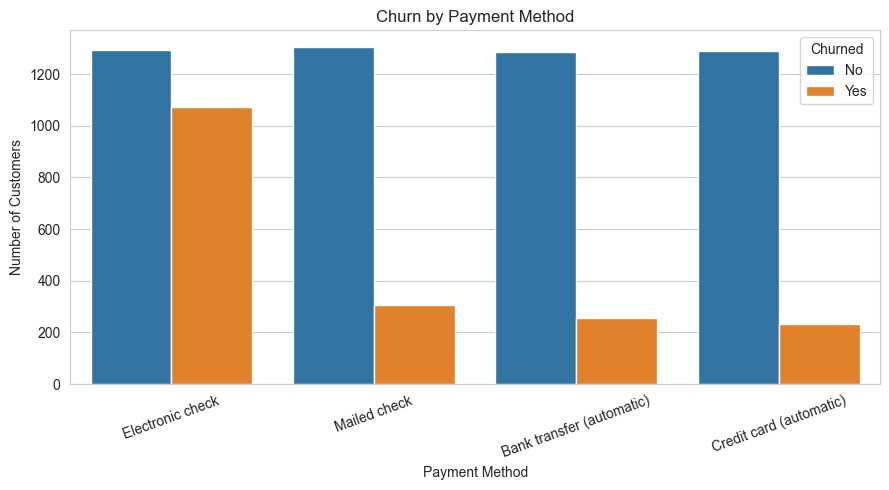

In [4]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churned")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/churn_by_payment_method.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Customers paying by **electronic check** churn far more than those on automatic bank transfer or credit card. Automatic payment methods are associated with stickier, more committed customers — nudging customers toward autopay could reduce churn.

## 5. Churn by tenure

**What:** Compare how long churned vs. retained customers have been with the company.

**Why:** Tenure measures loyalty over time and usually shows where in the customer lifecycle the risk is highest.

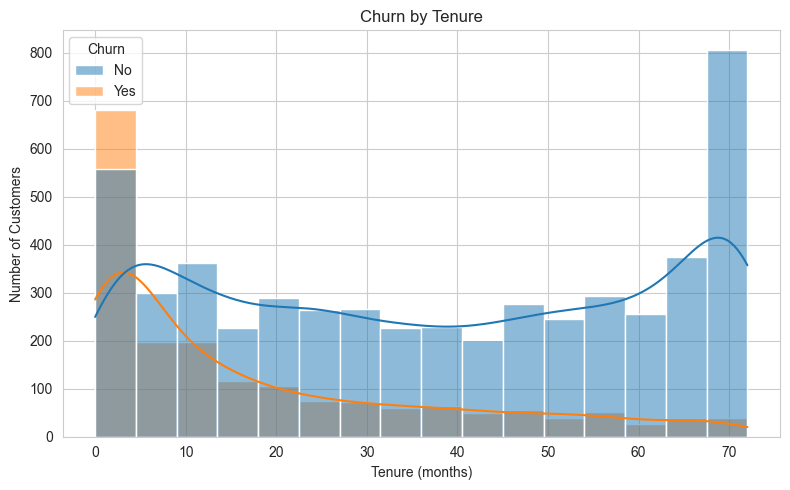

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True)
plt.title("Churn by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Churn is heavily concentrated in the **first few months** of tenure and drops sharply as customers stay longer. The early lifecycle is the danger zone — strong onboarding and early-tenure engagement would have the biggest impact.

## 6. Correlation between numeric features

**What:** Plot a correlation heatmap of the numeric columns.

**Why:** Highly correlated features carry redundant information; spotting this guides feature engineering in the next notebook.

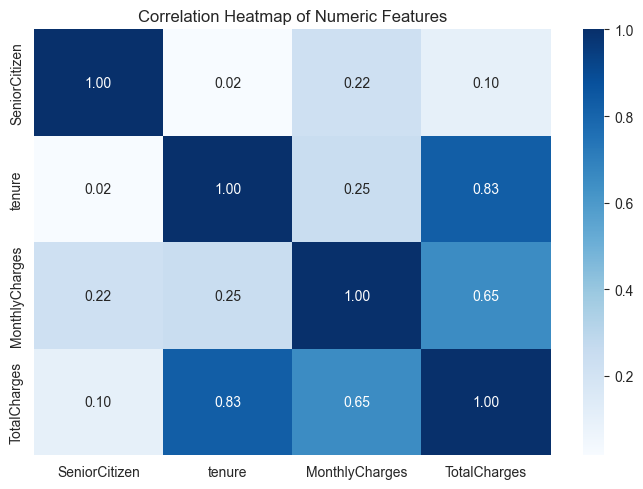

In [6]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** `TotalCharges` is strongly correlated with both `tenure` and `MonthlyCharges` — which makes sense, since total charges are essentially tenure × monthly charge. This redundancy is why we drop `TotalCharges` during feature engineering to avoid multicollinearity.

## Section conclusion — what the data is telling us

- **Contract type** is the strongest churn signal: month-to-month customers leave far more often.
- **High monthly charges (~$70-$110)** and **electronic-check payments** are both associated with higher churn.
- **Low-tenure customers** churn the most — the first few months are critical.
- **`TotalCharges` is redundant** (highly correlated with tenure and monthly charges) and will be dropped next.

All five figures are saved in `outputs/figures/`.

**Next:** Notebook 04 turns these raw columns into model-ready, encoded features.